## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## Data Loading

In [2]:
nav_history = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

scheme_perf = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


### Dataset Overview

In [3]:
print("NAV History Columns")
print(nav_history.columns.tolist())

print("\nBenchmark Columns")
print(benchmark.columns.tolist())

print("\nScheme Performance Columns")
print(scheme_perf.columns.tolist())

NAV History Columns
['amfi_code', 'date', 'nav']

Benchmark Columns
['date', 'index_name', 'close_value']

Scheme Performance Columns
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'expense_ratio_flag']


## Daily Return Analysis

In [4]:
# Convert date column

nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

# Sort values

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

# Daily Return Calculation

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove first NaN return for each scheme

daily_returns = nav_history.dropna(
    subset=["daily_return"]
)

print("Daily Returns Calculated Successfully")

daily_returns.head()

Daily Returns Calculated Successfully


,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


### Daily Return Distribution

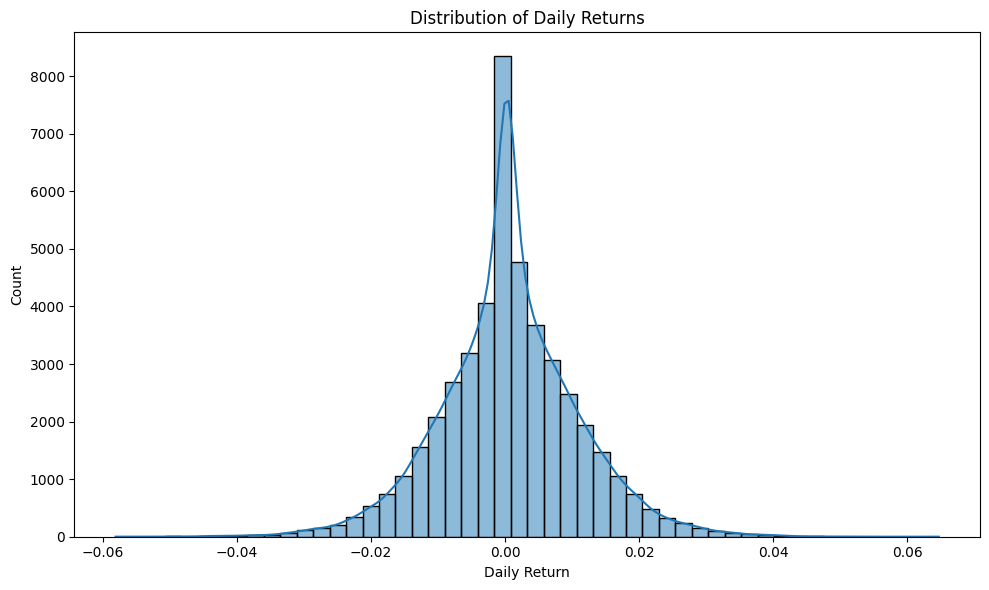

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    daily_returns["daily_return"],
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.tight_layout()

plt.show()

### Daily Return Summary Statistics

In [6]:
print(
    daily_returns["daily_return"].describe()
)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


### Observation

The daily return distribution is centered close to zero and exhibits normal market volatility. Most daily returns fall within a narrow range, while extreme positive and negative movements are relatively rare.

## CAGR Analysis (1 Year, 3 Year, 5 Year)

### CAGR Comparison Analysis

In [13]:
# CAGR comparison table

cagr_table = scheme_perf[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].copy()

# Best performers by 5 year CAGR

cagr_table = cagr_table.sort_values(
    by="return_5yr_pct",
    ascending=False
)

print("Top Funds by 5 Year CAGR")

cagr_table.head(10)

Top Funds by 5 Year CAGR


,amfi_code,scheme_name,fund_house,return_1yr_pct,return_3yr_pct,return_5yr_pct
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,24.93,22.38,23.80
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,21.97,20.98,22.62
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,21.30,20.15,21.88
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,20.59,23.14,21.82
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,24.56,23.39,20.67
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,20.20,20.08,20.61
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,14.12,17.16,19.00
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,14.88,15.18,18.94
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,17.12,18.23,17.75
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,15.43,16.58,17.69


### CAGR Distribution

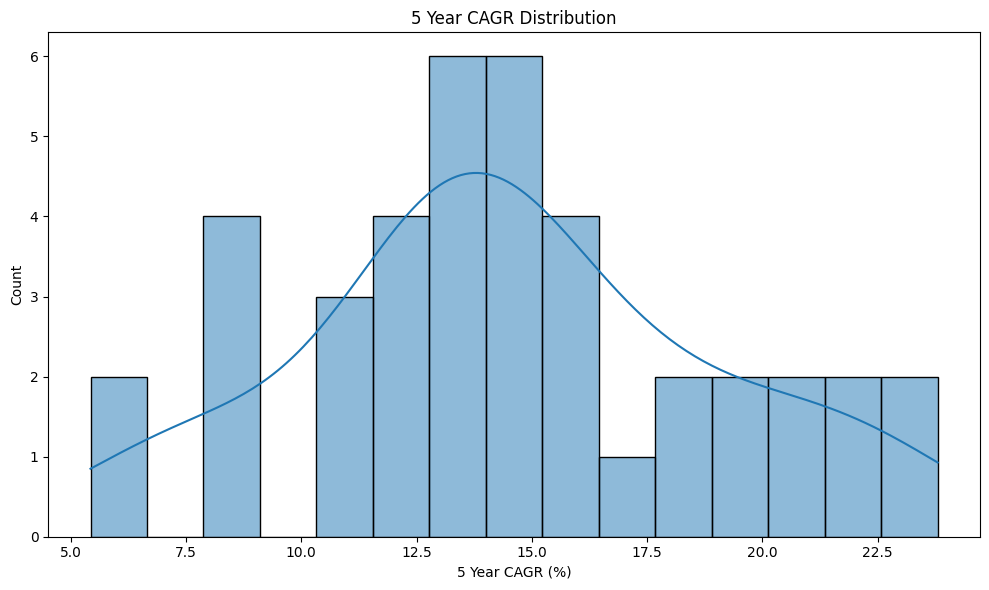

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    cagr_table["return_5yr_pct"],
    bins=15,
    kde=True
)

plt.title("5 Year CAGR Distribution")

plt.xlabel("5 Year CAGR (%)")

plt.tight_layout()

plt.show()

### Save CAGR CSV

In [15]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR Comparison CSV Saved")

CAGR Comparison CSV Saved


### Observation

Most schemes delivered positive long-term returns over the analysis period. Small-cap funds dominate the top ranks, indicating stronger long-term growth potential compared to many large-cap and diversified schemes.

### Sharpe Ratio Analysis

In [16]:
RISK_FREE_RATE = 6.5

sharpe_table = scheme_perf[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "sharpe_ratio",
        "std_dev_ann_pct",
        "return_3yr_pct"
    ]
].copy()

sharpe_table = sharpe_table.sort_values(
    by="sharpe_ratio",
    ascending=False
)

print("Top 10 Funds by Sharpe Ratio")

sharpe_table.head(10)

Top 10 Funds by Sharpe Ratio


,amfi_code,scheme_name,fund_house,sharpe_ratio,std_dev_ann_pct,return_3yr_pct
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,7.68,0.5,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,6.18,0.5,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,5.14,0.5,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.84,4.0,7.37
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,1.52,4.0,6.07
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,1.33,4.0,5.31
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.06,14.0,14.81
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.06,14.0,14.84
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.03,14.0,14.41
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.00,14.0,14.00


### Sharpe Ratio Visulization

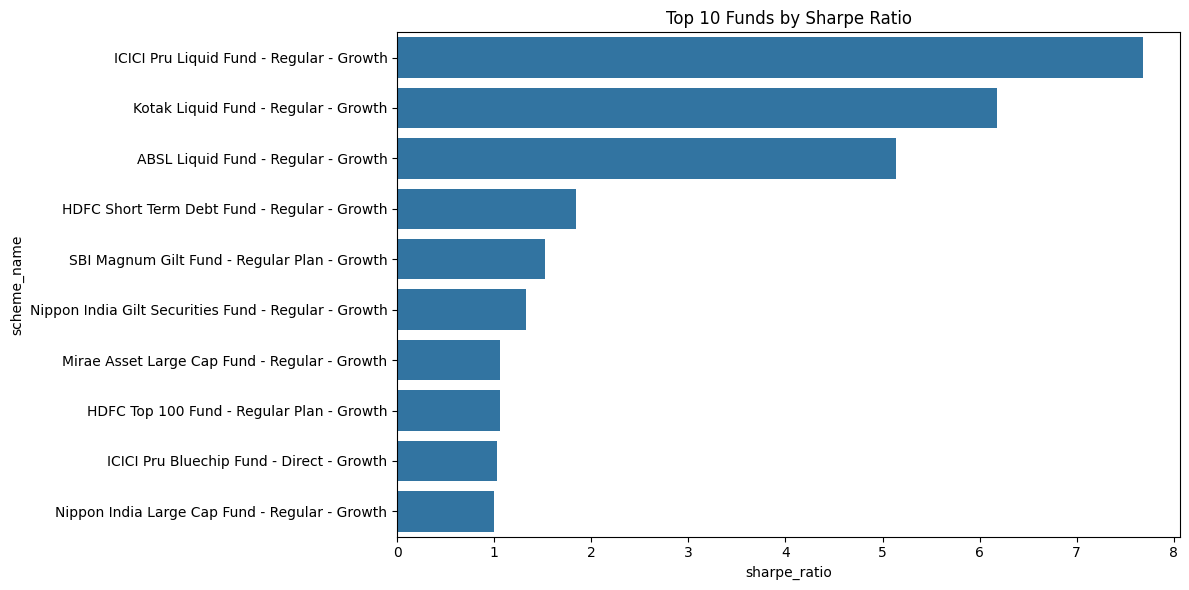

In [17]:
top10_sharpe = sharpe_table.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sharpe_ratio_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Export CSV

In [18]:
sharpe_table.to_csv(
    "../reports/sharpe_ratio_ranking.csv",
    index=False
)

print("Sharpe Ratio Ranking Saved")

Sharpe Ratio Ranking Saved


### Observation

Funds with higher Sharpe ratios generated better risk-adjusted returns. These schemes delivered more return per unit of risk and therefore rank higher in overall investment efficiency.

## Sortino Ratio Analysis

In [19]:
sortino_table = scheme_perf[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "sortino_ratio"
    ]
].copy()

sortino_table = sortino_table.sort_values(
    by="sortino_ratio",
    ascending=False
)

print("Top 10 Funds by Sortino Ratio")

sortino_table.head(10)

Top 10 Funds by Sortino Ratio


,amfi_code,scheme_name,fund_house,sortino_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,10.37
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,9.70
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,8.76
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,2.79
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,2.38
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,2.11
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.70
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.68
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,1.67
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.66


### Sortino Ratio Chart

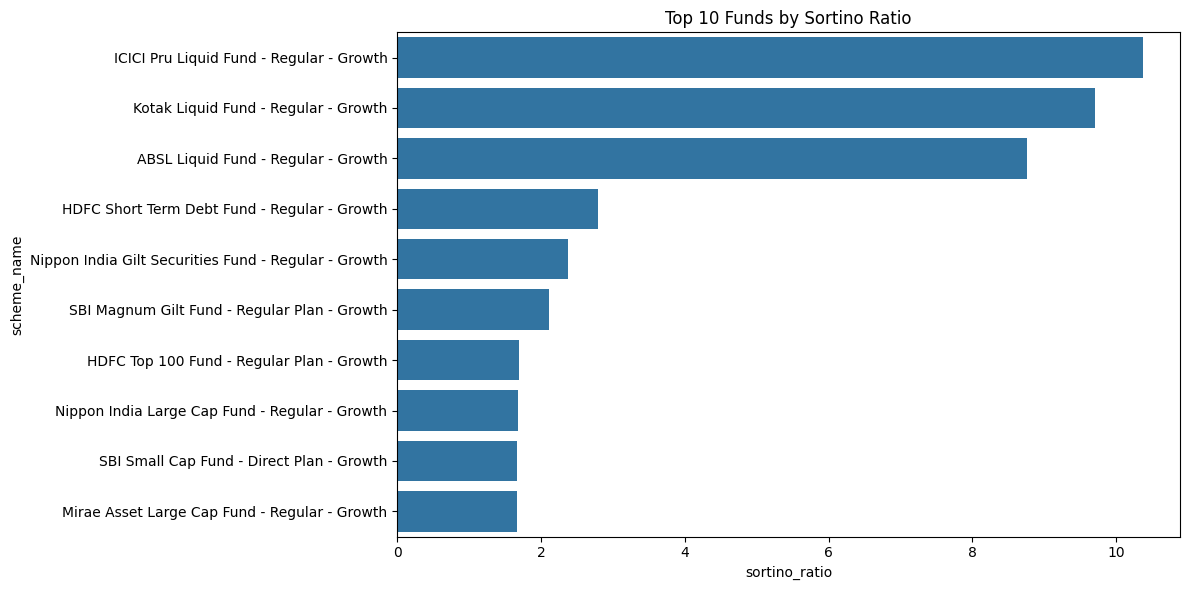

In [20]:
top10_sortino = sortino_table.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sortino_ratio_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Export CSV

In [21]:
sortino_table.to_csv(
    "../reports/sortino_ratio_ranking.csv",
    index=False
)

print("Sortino Ratio Ranking Saved")

Sortino Ratio Ranking Saved


### Observation

Funds with higher Sortino ratios demonstrated stronger downside-risk-adjusted performance. These schemes were more effective in generating returns while minimizing negative return volatility.

## Alpha and Beta Analysis

Prepare NIFTY100 Return

In [23]:
# Date conversion

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Select NIFTY100

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Sort

nifty100 = nifty100.sort_values(
    "date"
)

# Daily Returns

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna()

print("NIFTY100 Returns Prepared")

NIFTY100 Returns Prepared


### Alpha Beta Calculation

In [24]:
alpha_beta_results = []

for scheme in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == scheme
    ].copy()

    fund_data = fund_data.sort_values(
        "date"
    )

    fund_data["fund_return"] = (
        fund_data["nav"]
        .pct_change()
    )

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["fund_return"]
    )

    alpha_beta_results.append(
        [
            scheme,
            intercept * 252,
            slope
        ]
    )

alpha_beta = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


### Export CSV

In [25]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully


### Top Alpha Funds

In [26]:
top_alpha = alpha_beta.sort_values(
    by="alpha",
    ascending=False
)

top_alpha.head(10)

,amfi_code,alpha,beta
21,119598,0.303370,-0.023196
39,149324,0.300579,0.011455
25,120505,0.292636,0.000549
36,148569,0.282704,0.018134
30,120843,0.273305,-0.022830
2,100033,0.271954,0.005104
34,148567,0.269838,0.023684
38,149323,0.265986,-0.002523
16,119094,0.260767,-0.066265
19,119551,0.232010,-0.031751


### Chart - Top Alpha Funds

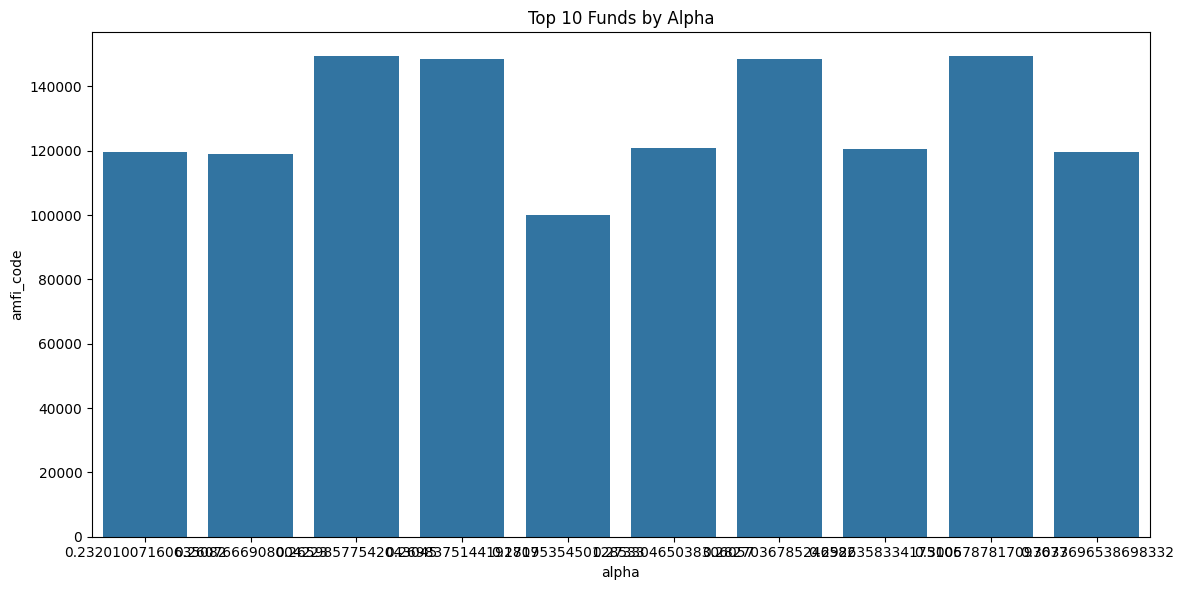

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha.head(10),
    x="alpha",
    y="amfi_code"
)

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_alpha_funds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Funds with positive alpha generated returns above what would be expected based on their market exposure. Beta values indicate the sensitivity of fund returns to movements in the NIFTY100 benchmark.

## Maximum Drawdown Analysis

### Maximum Drawdown Calculation

In [28]:
max_drawdown_results = []

for scheme in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == scheme
    ].copy()

    fund_data = fund_data.sort_values(
        "date"
    )

    running_max = fund_data["nav"].cummax()

    drawdown = (
        fund_data["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    max_drawdown_results.append(
        [
            scheme,
            max_dd
        ]
    )

max_drawdown_df = pd.DataFrame(
    max_drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

max_drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


### Worst Drawdown Funds

In [29]:
worst_drawdown = max_drawdown_df.sort_values(
    by="max_drawdown"
)

worst_drawdown.head(10)

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060
7,102886,-0.280011
0,100016,-0.247344
29,120842,-0.240035
11,118634,-0.233449
15,119093,-0.217514


### Chart

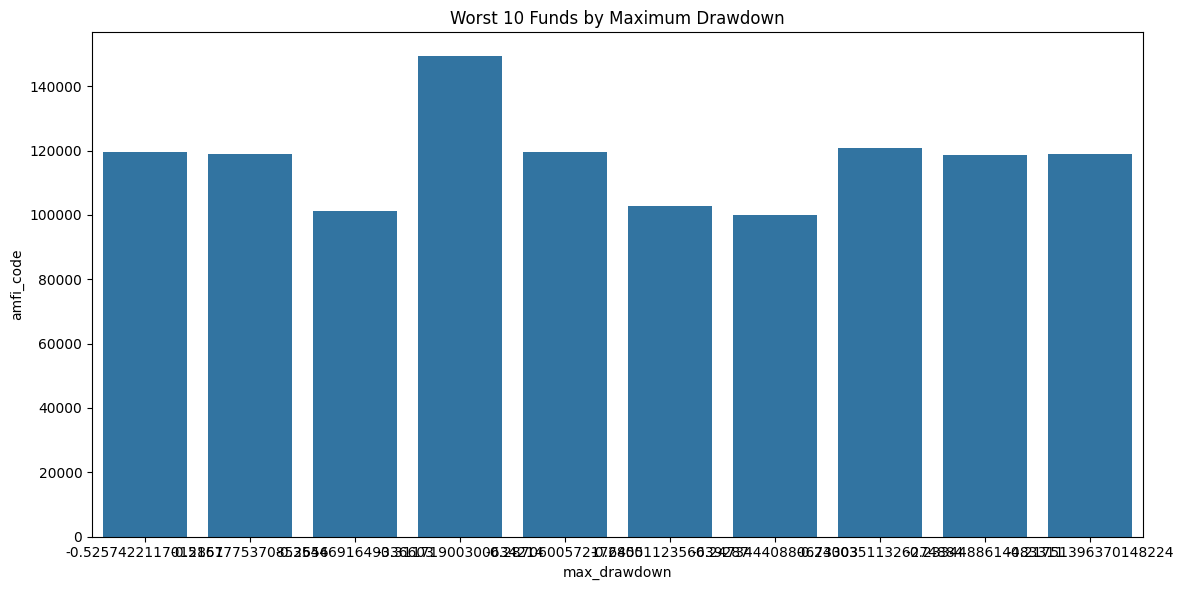

In [30]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_drawdown.head(10),
    x="max_drawdown",
    y="amfi_code"
)

plt.title("Worst 10 Funds by Maximum Drawdown")

plt.tight_layout()

plt.savefig(
    "../reports/charts/max_drawdown_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Maximum drawdown measures the largest decline from a previous NAV peak. Funds with lower drawdowns demonstrated better downside protection during market corrections.

## Fund Scorecard (0–100)

### Marge Metrics

In [31]:
scorecard = scheme_perf[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "sharpe_ratio",
        "expense_ratio_pct"
    ]
].copy()

scorecard = scorecard.merge(
    alpha_beta,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    max_drawdown_df,
    on="amfi_code",
    how="left"
)

### Create Ranks

In [32]:
scorecard["return_rank"] = scorecard[
    "return_3yr_pct"
].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio"
].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard[
    "alpha"
].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard[
    "expense_ratio_pct"
].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard[
    "max_drawdown"
].rank(
    ascending=False
)

### Final Score

In [33]:
scorecard["fund_score"] = (

    0.30 * scorecard["return_rank"]

    +

    0.25 * scorecard["sharpe_rank"]

    +

    0.20 * scorecard["alpha_rank"]

    +

    0.15 * scorecard["expense_rank"]

    +

    0.10 * scorecard["drawdown_rank"]

)

scorecard = scorecard.sort_values(
    by="fund_score"
)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,sharpe_ratio,expense_ratio_pct,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,1.43,0.303370,-0.023196,-0.287060,1.0,18.0,1.0,21.0,36.0,11.750
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,0.98,1.45,0.273305,-0.022830,-0.129740,11.0,12.0,5.0,22.0,13.0,11.900
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,0.95,1.36,0.292636,0.000549,-0.181885,8.0,17.0,3.0,15.0,25.0,12.000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.06,1.46,0.269838,0.023684,-0.112657,17.0,7.5,7.0,23.0,8.0,12.625
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,1.03,0.80,0.211948,0.016232,-0.125883,20.0,9.0,13.0,12.0,12.0,13.850
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,0.87,1.38,0.271954,0.005104,-0.162172,10.0,29.0,6.0,17.0,20.0,16.000
15,118632,Nippon India Large Cap Fund - Regular - Growth,14.00,1.00,1.51,0.218294,-0.008354,-0.174141,21.0,10.0,11.0,24.5,23.0,16.975
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,0.72,0.048824,0.062002,-0.525742,2.0,19.5,36.0,5.5,40.0,17.500
13,120506,ICICI Pru Value Discovery Fund - Regular - Growth,14.76,0.98,1.41,0.162539,0.041896,-0.198257,18.0,12.0,20.0,19.0,27.0,17.950
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,13.38,0.96,0.92,0.177298,0.048820,-0.152000,24.0,15.0,16.0,14.0,18.0,18.050


### Save CSV

In [34]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully")

fund_scorecard.csv saved successfully


## Benchmark Comparison Analysis

### Top 5 Funds Select

In [35]:
top5_funds = scorecard.head(5)[
    "amfi_code"
].tolist()

top5_funds

[119598, 120843, 120505, 148567, 120504]

### Prepare Benchmark Data

In [36]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark_filtered = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
].copy()

### Benchmark Comparison Chart

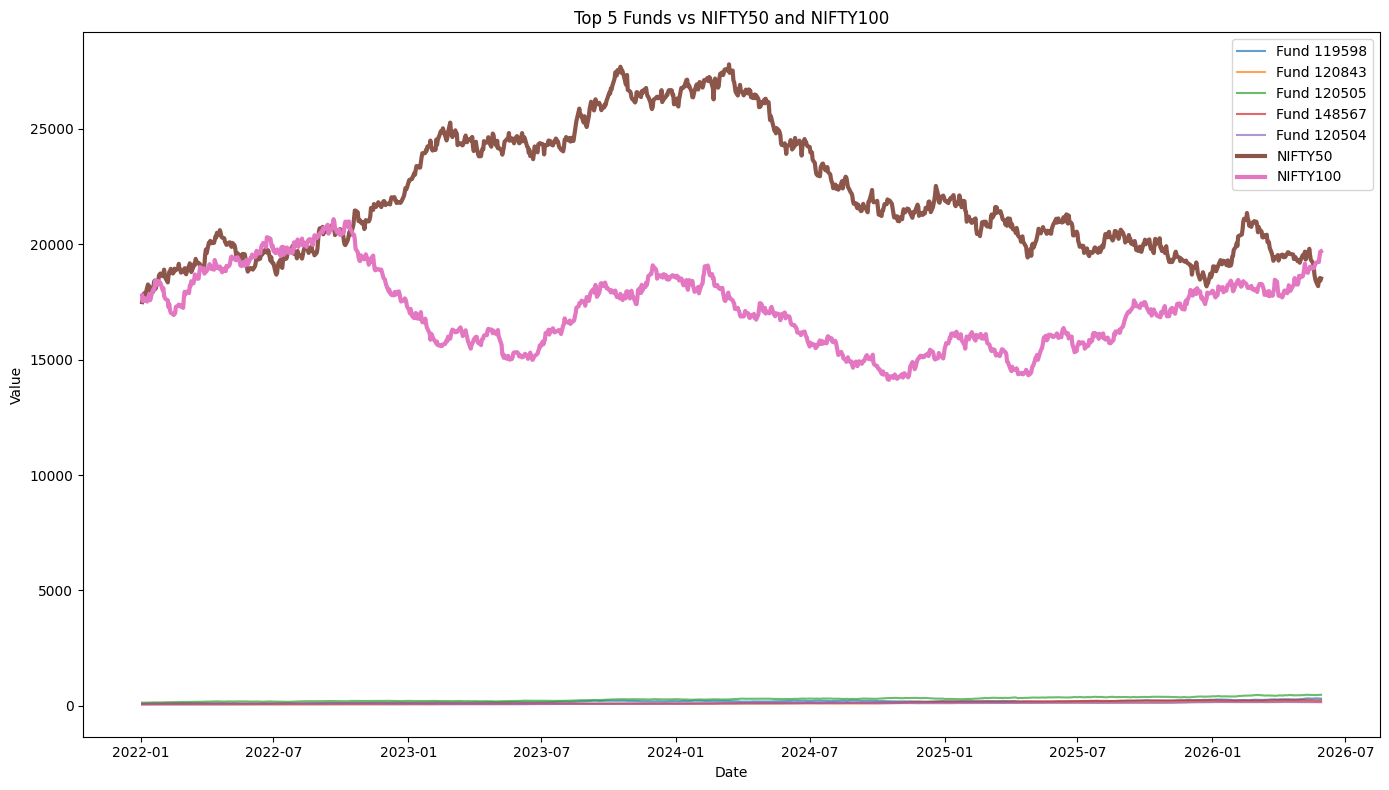

In [37]:
plt.figure(figsize=(14,8))

# Top 5 Funds

for fund in top5_funds:

    temp = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values(
        "date"
    )

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.7,
        label=f"Fund {fund}"
    )

# Benchmarks

for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_filtered[
        benchmark_filtered["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        linewidth=3,
        label=idx
    )

plt.title(
    "Top 5 Funds vs NIFTY50 and NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Tracking Error Analysis

In [38]:
tracking_error_results = []

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

for fund in top5_funds:

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values(
        "date"
    )

    fund_data["fund_return"] = (
        fund_data["nav"]
        .pct_change()
    )

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["fund_return"] -
         merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append(
        [fund, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,119598,0.283881
1,120843,0.206425
2,120505,0.231968
3,148567,0.189664
4,120504,0.191587


### Save Tracking Error

In [39]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved successfully")

tracking_error.csv saved successfully


### Observation

The benchmark comparison highlights how the top-ranked funds performed relative to NIFTY50 and NIFTY100. Tracking error measures the consistency of a fund relative to its benchmark, with lower values indicating closer benchmark tracking.